CARCINOGEN DATASET ANALYSIS - NATURE JOURNAL STYLE
Features:
- Times New Roman font throughout (BOLD)
- No grid lines
- Colorblind-friendly palette
- All axes properly labeled
- EDITABLE VECTOR GRAPHICS (SVG/EPS) in working directory
- Chemical structures for functional groups
- Fully editable in Illustrator, Inkscape, CorelDRAW
Reading file: 致癌物.csv
Total compounds: 213


Analyzing molecules: 100%|██████████| 213/213 [00:00<00:00, 741.61it/s]



Processing complete!
Valid molecules: 213/213 (100.0%)
Time elapsed: 0.3 seconds

Functional group statistics saved to: carcinogen_fg_statistics.csv
Detailed results saved to: carcinogen_fg_analysis_results.xlsx

CARCINOGEN DATASET STATISTICAL SUMMARY

Dataset size: 213 compounds
Valid molecules: 213 (100.0%)

Physicochemical properties (mean ± s.d.)
  Molecular weight  : 145.9 ± 99.3
  LogP              : 1.7 ± 2.3
  H-bond donors     : 0.4 ± 0.7
  H-bond acceptors  : 1.4 ± 1.8
  Rotatable bonds   : 2.9 ± 3.9
  Total rings       : 0.8 ± 1.3

Functional group prevalence (top 5)
  Aromatic_ring            : 39.9% (avg 0.67 per molecule)
  Ether                    : 20.7% (avg 0.29 per molecule)
  Alkene                   : 17.4% (avg 0.18 per molecule)
  Chloride                 : 15.5% (avg 0.30 per molecule)
  Ester                    : 10.8% (avg 0.14 per molecule)

Generating EDITABLE VECTOR GRAPHICS (SVG/EPS)...
Files saved directly to current working directory
These files are FUL

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  ✓ Saved editable EPS: Fig1_FG_Distribution_with_structures_with_structures.eps


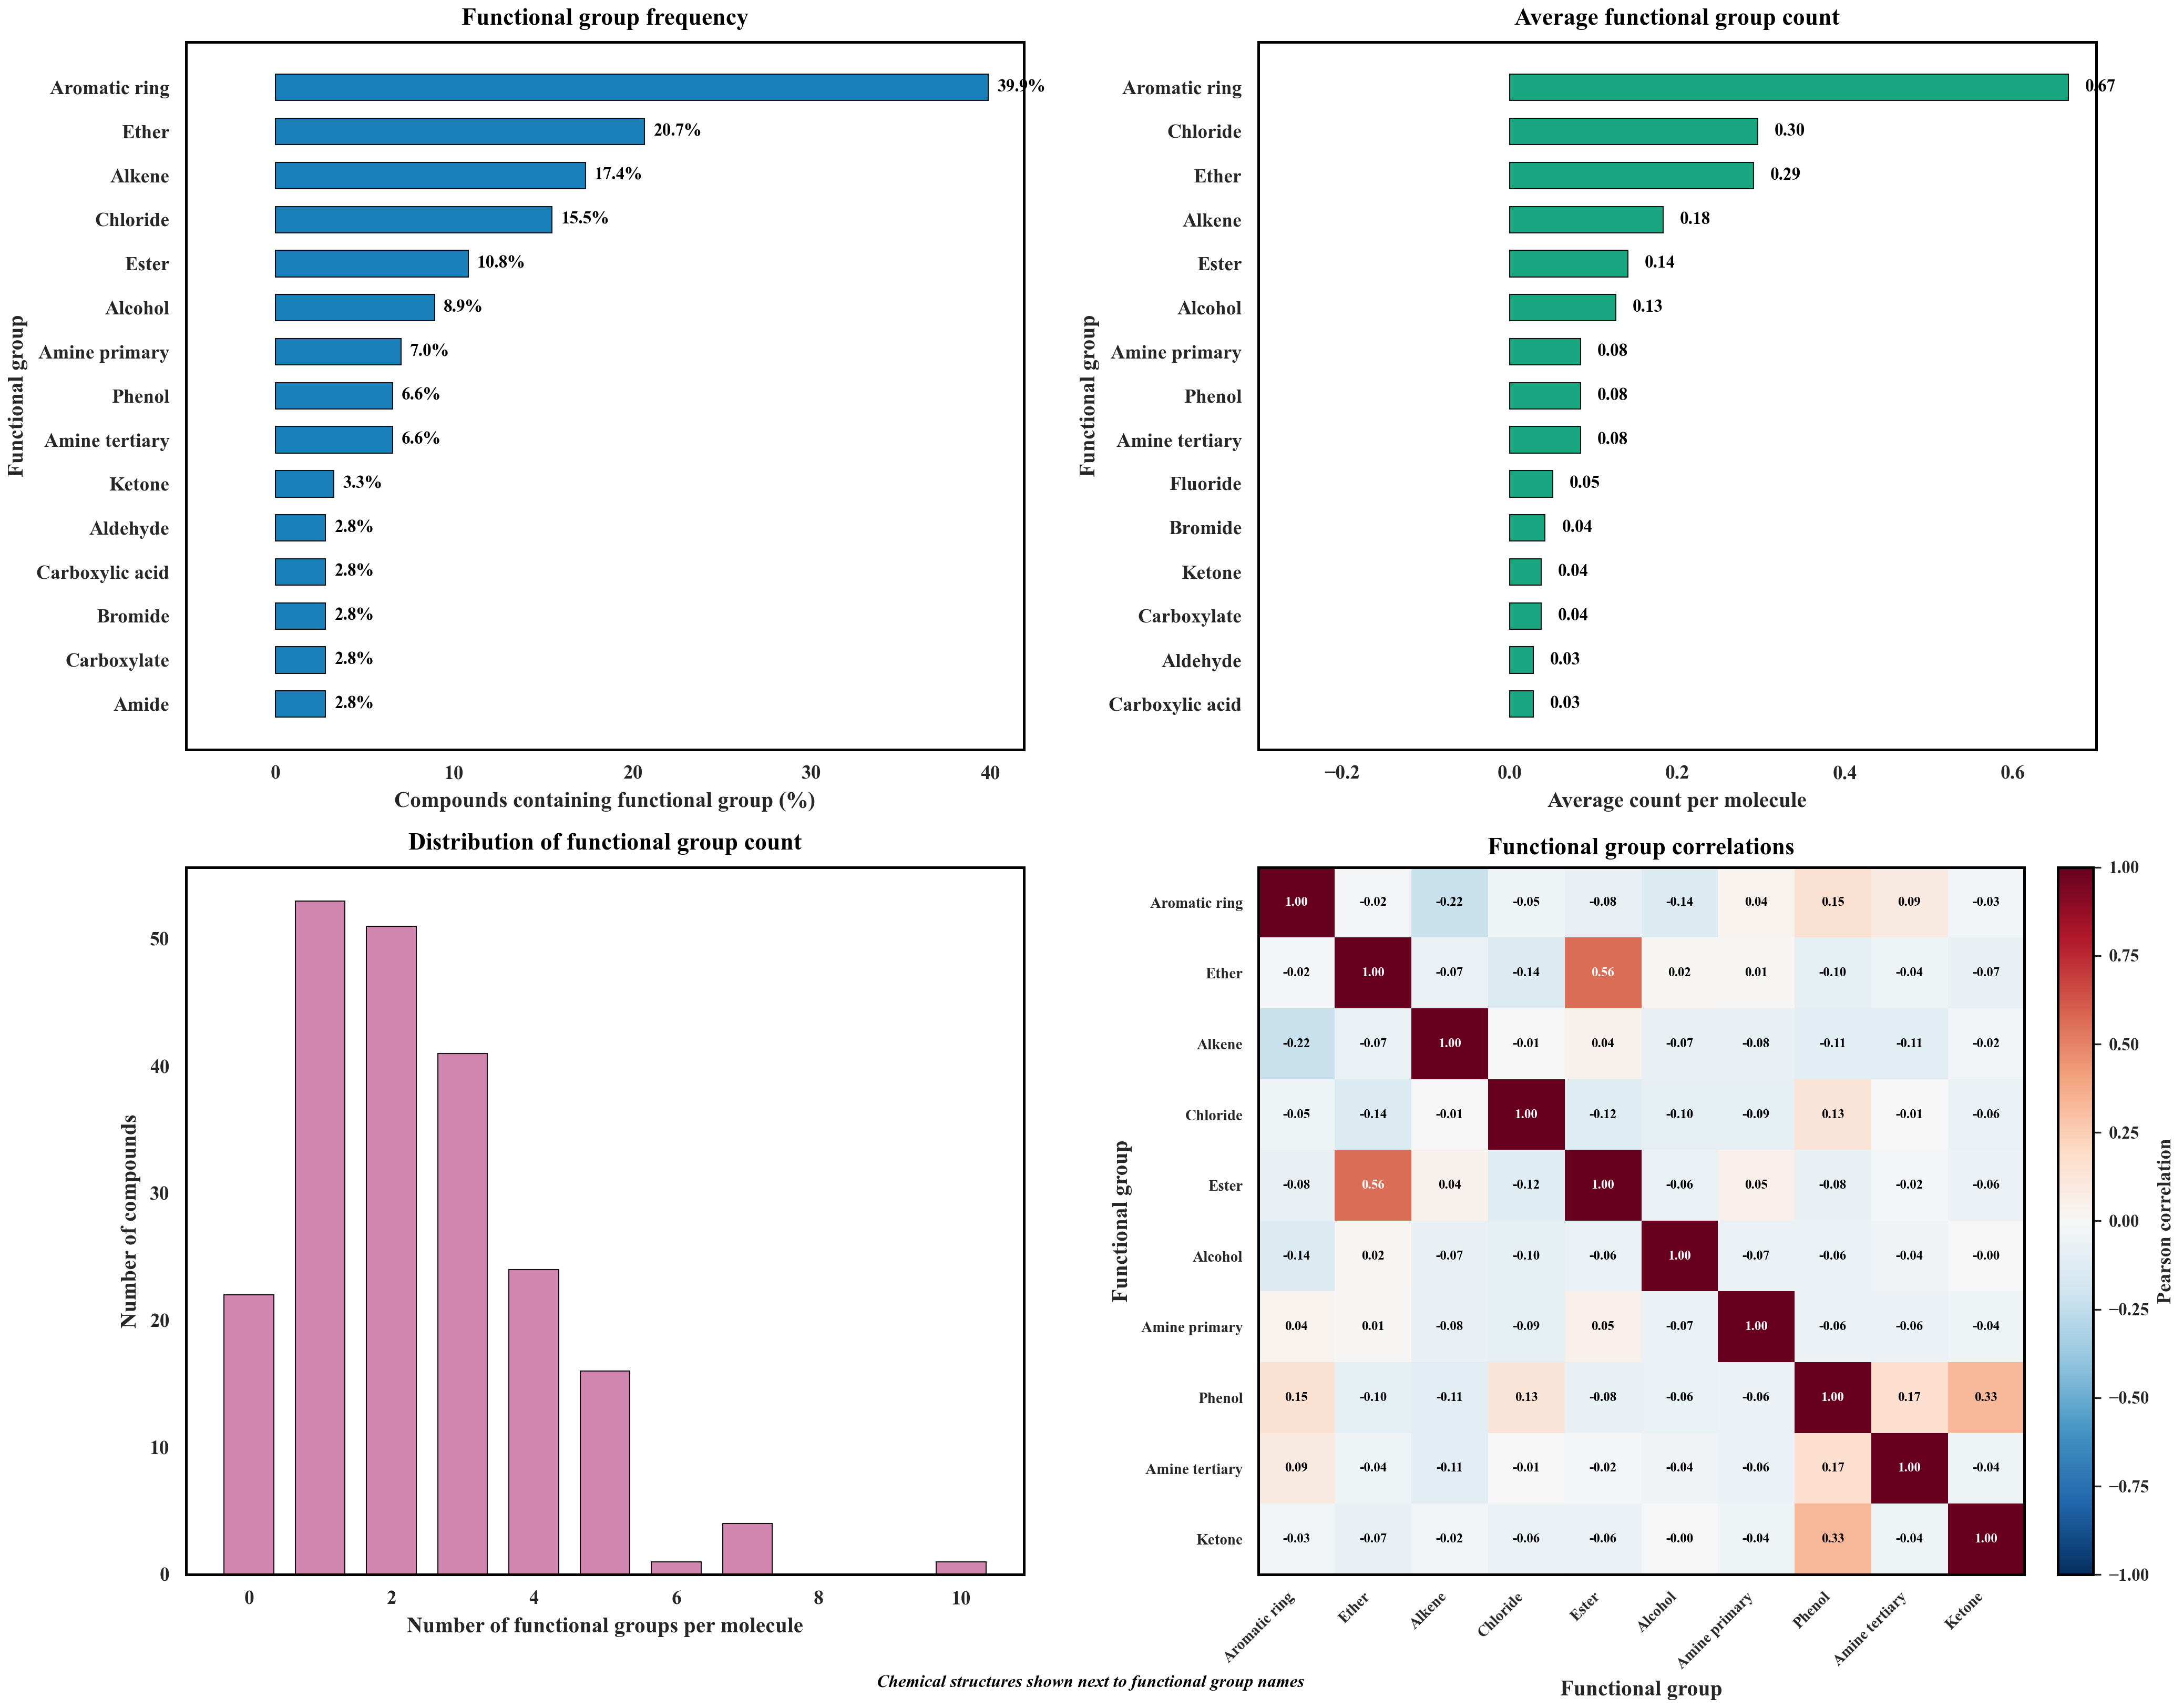


Figure 1b: Functional Group Distribution (without structures)
  ✓ Saved editable SVG: Fig1_FG_Distribution_no_structures.svg


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  ✓ Saved editable EPS: Fig1_FG_Distribution_no_structures.eps


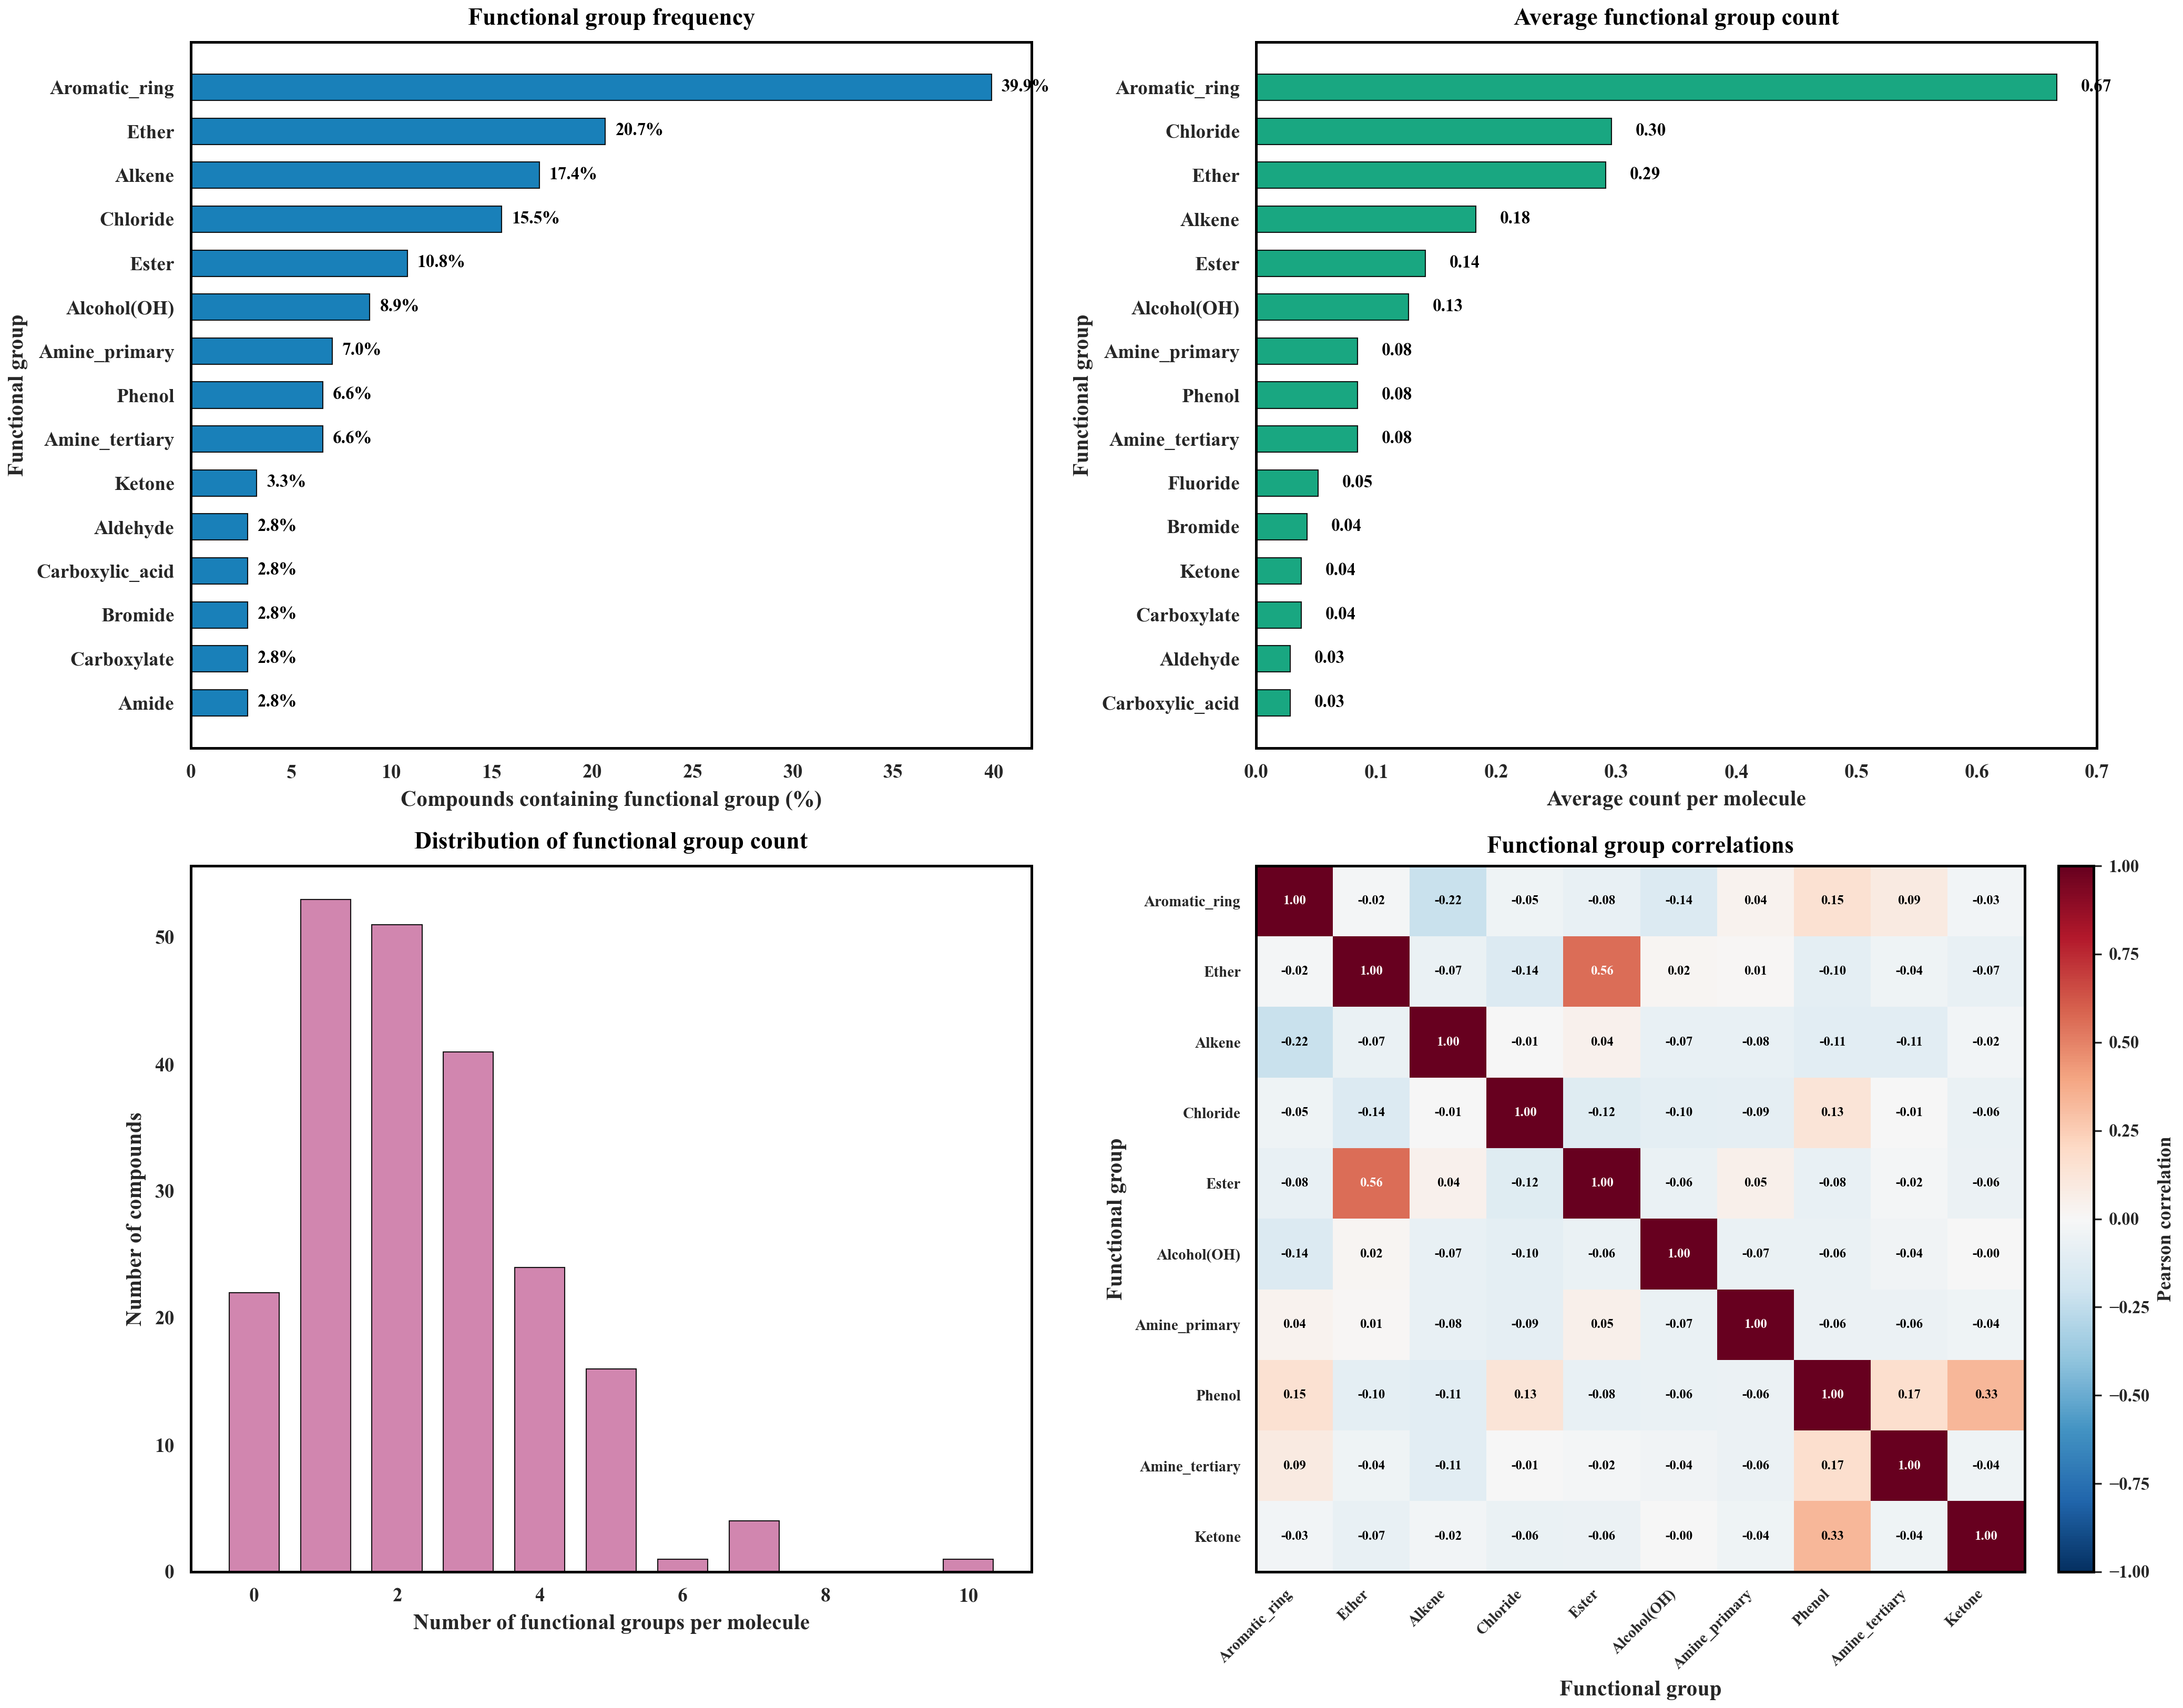


Figure 2: Property Distributions
  ✓ Saved editable SVG: Fig2_Property_Distributions.svg


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  ✓ Saved editable EPS: Fig2_Property_Distributions.eps


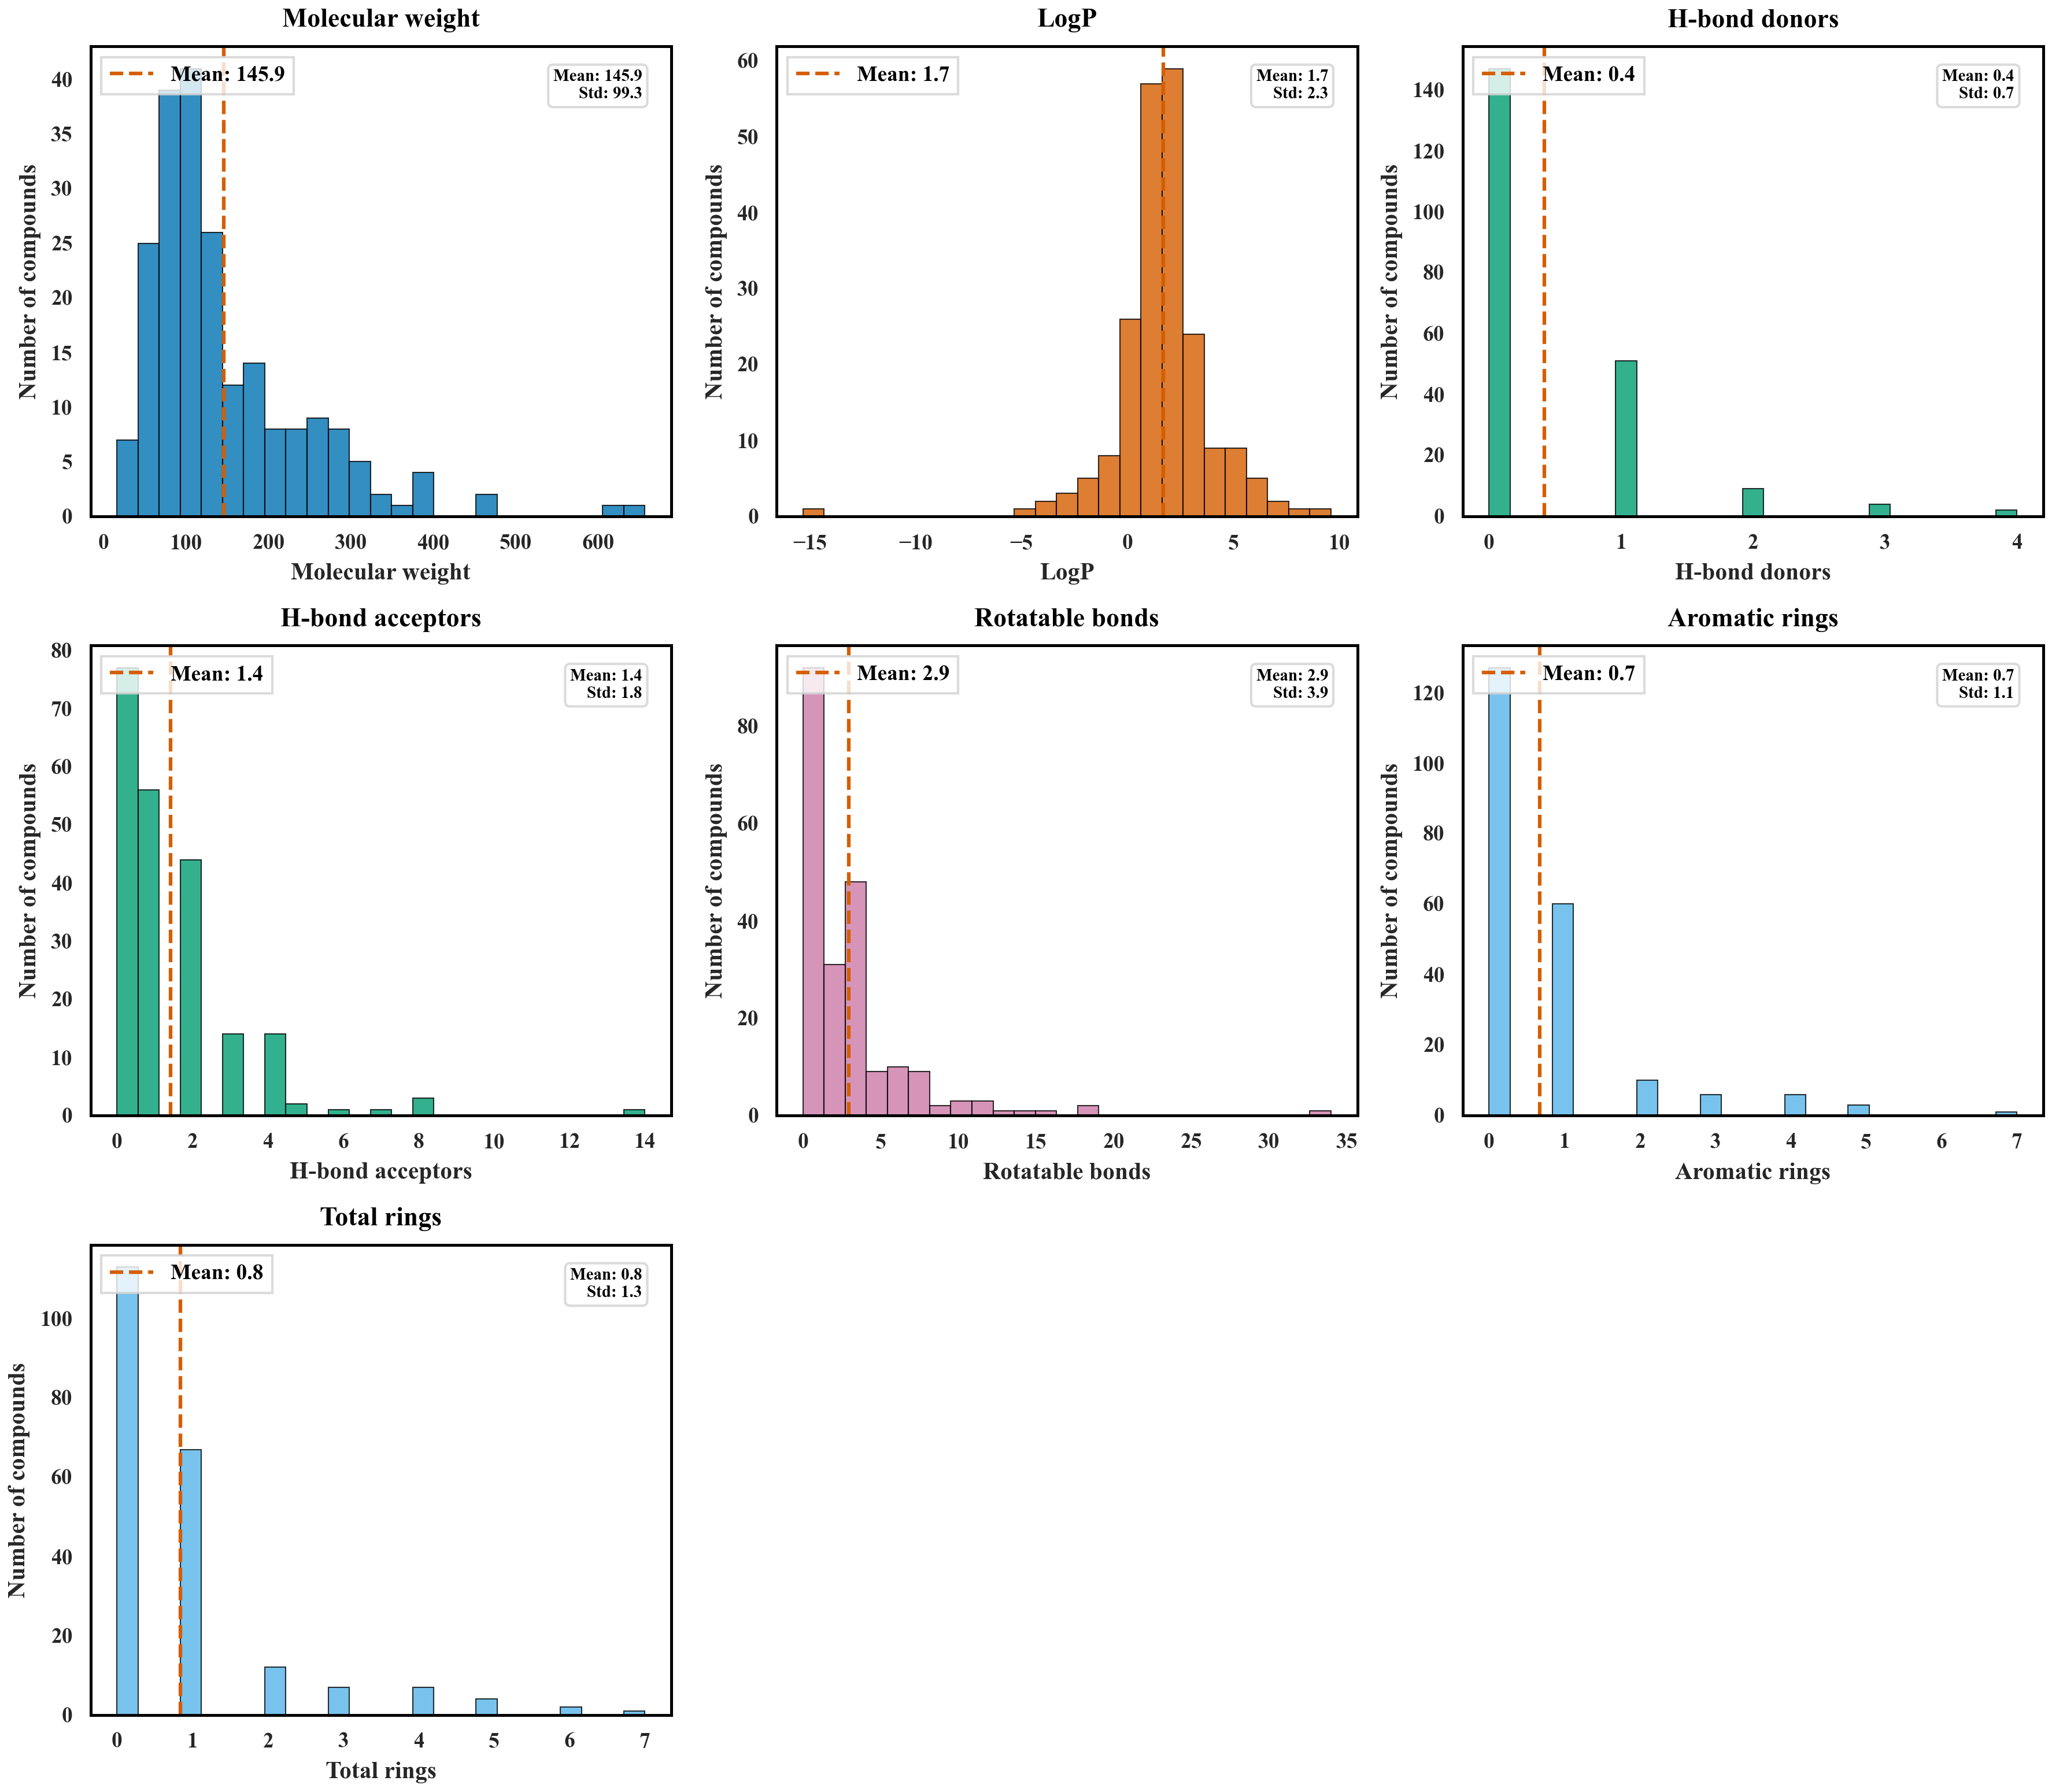


Figure 3: Compound Classification
  ✓ Saved editable SVG: Fig3_Compound_Classification.svg
  ✓ Saved editable EPS: Fig3_Compound_Classification.eps


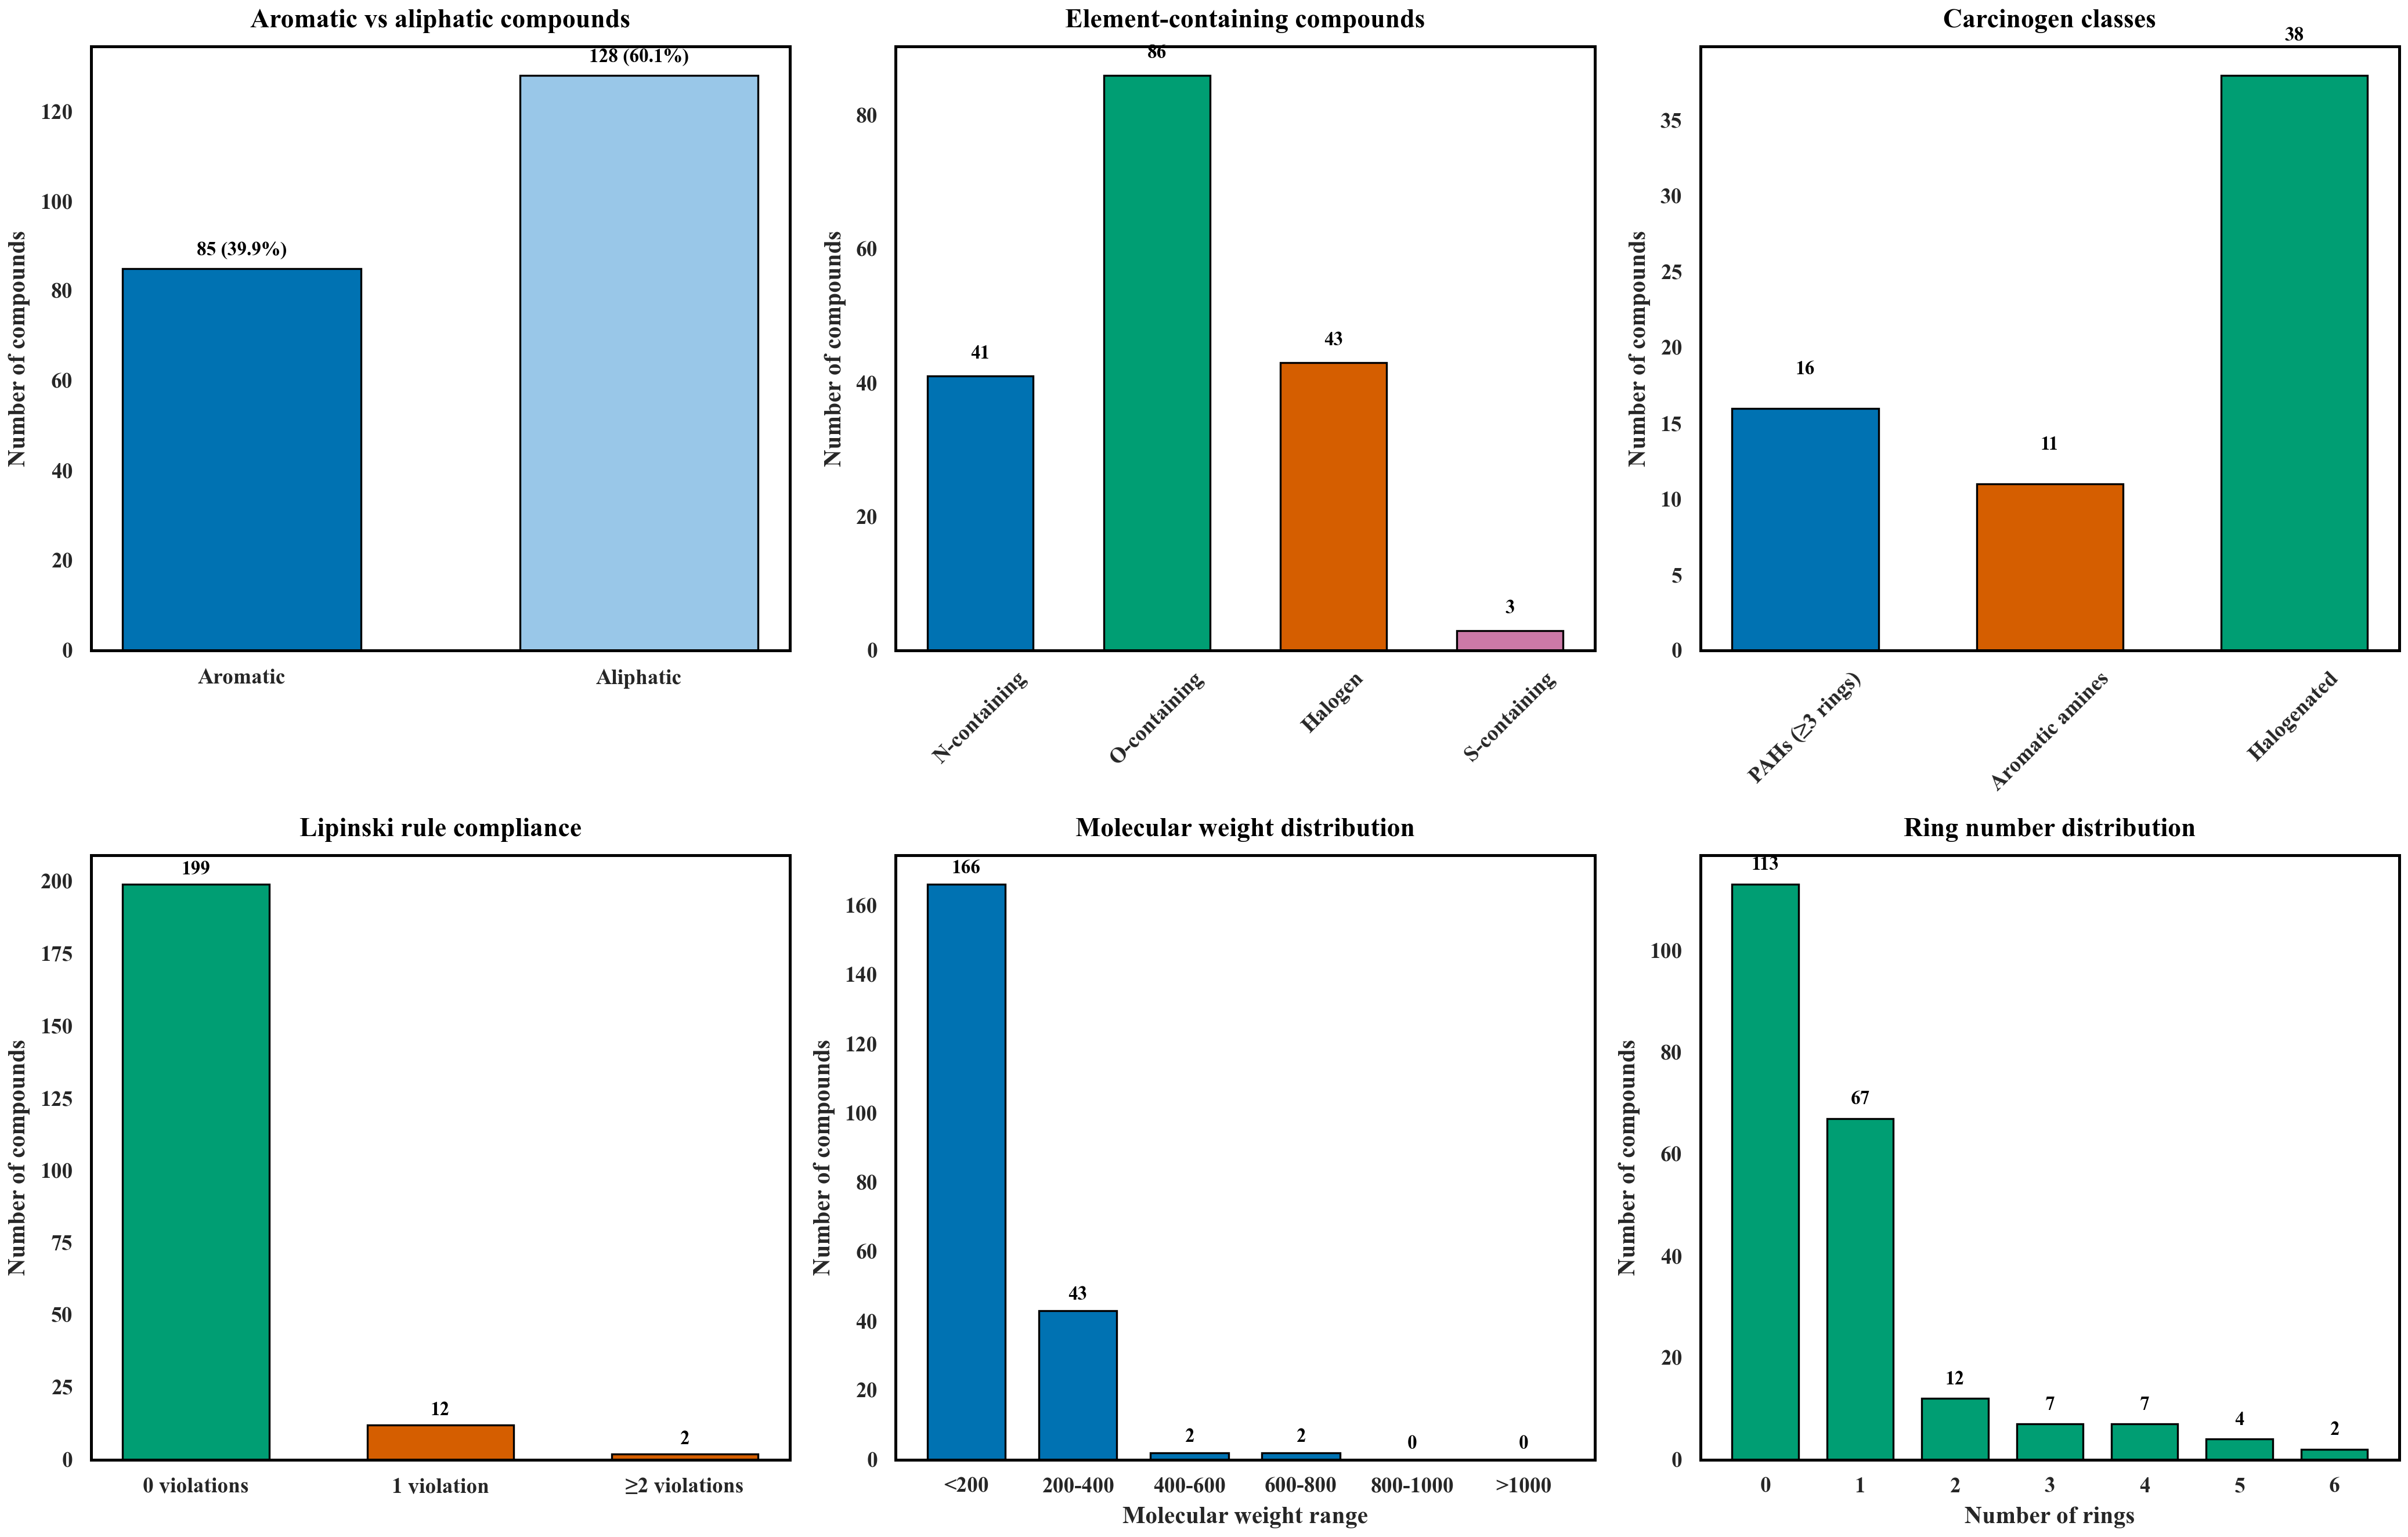


Figure 4: Scatter Matrix
  ✓ Saved editable SVG: Fig4_Scatter_Matrix.svg


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  ✓ Saved editable EPS: Fig4_Scatter_Matrix.eps


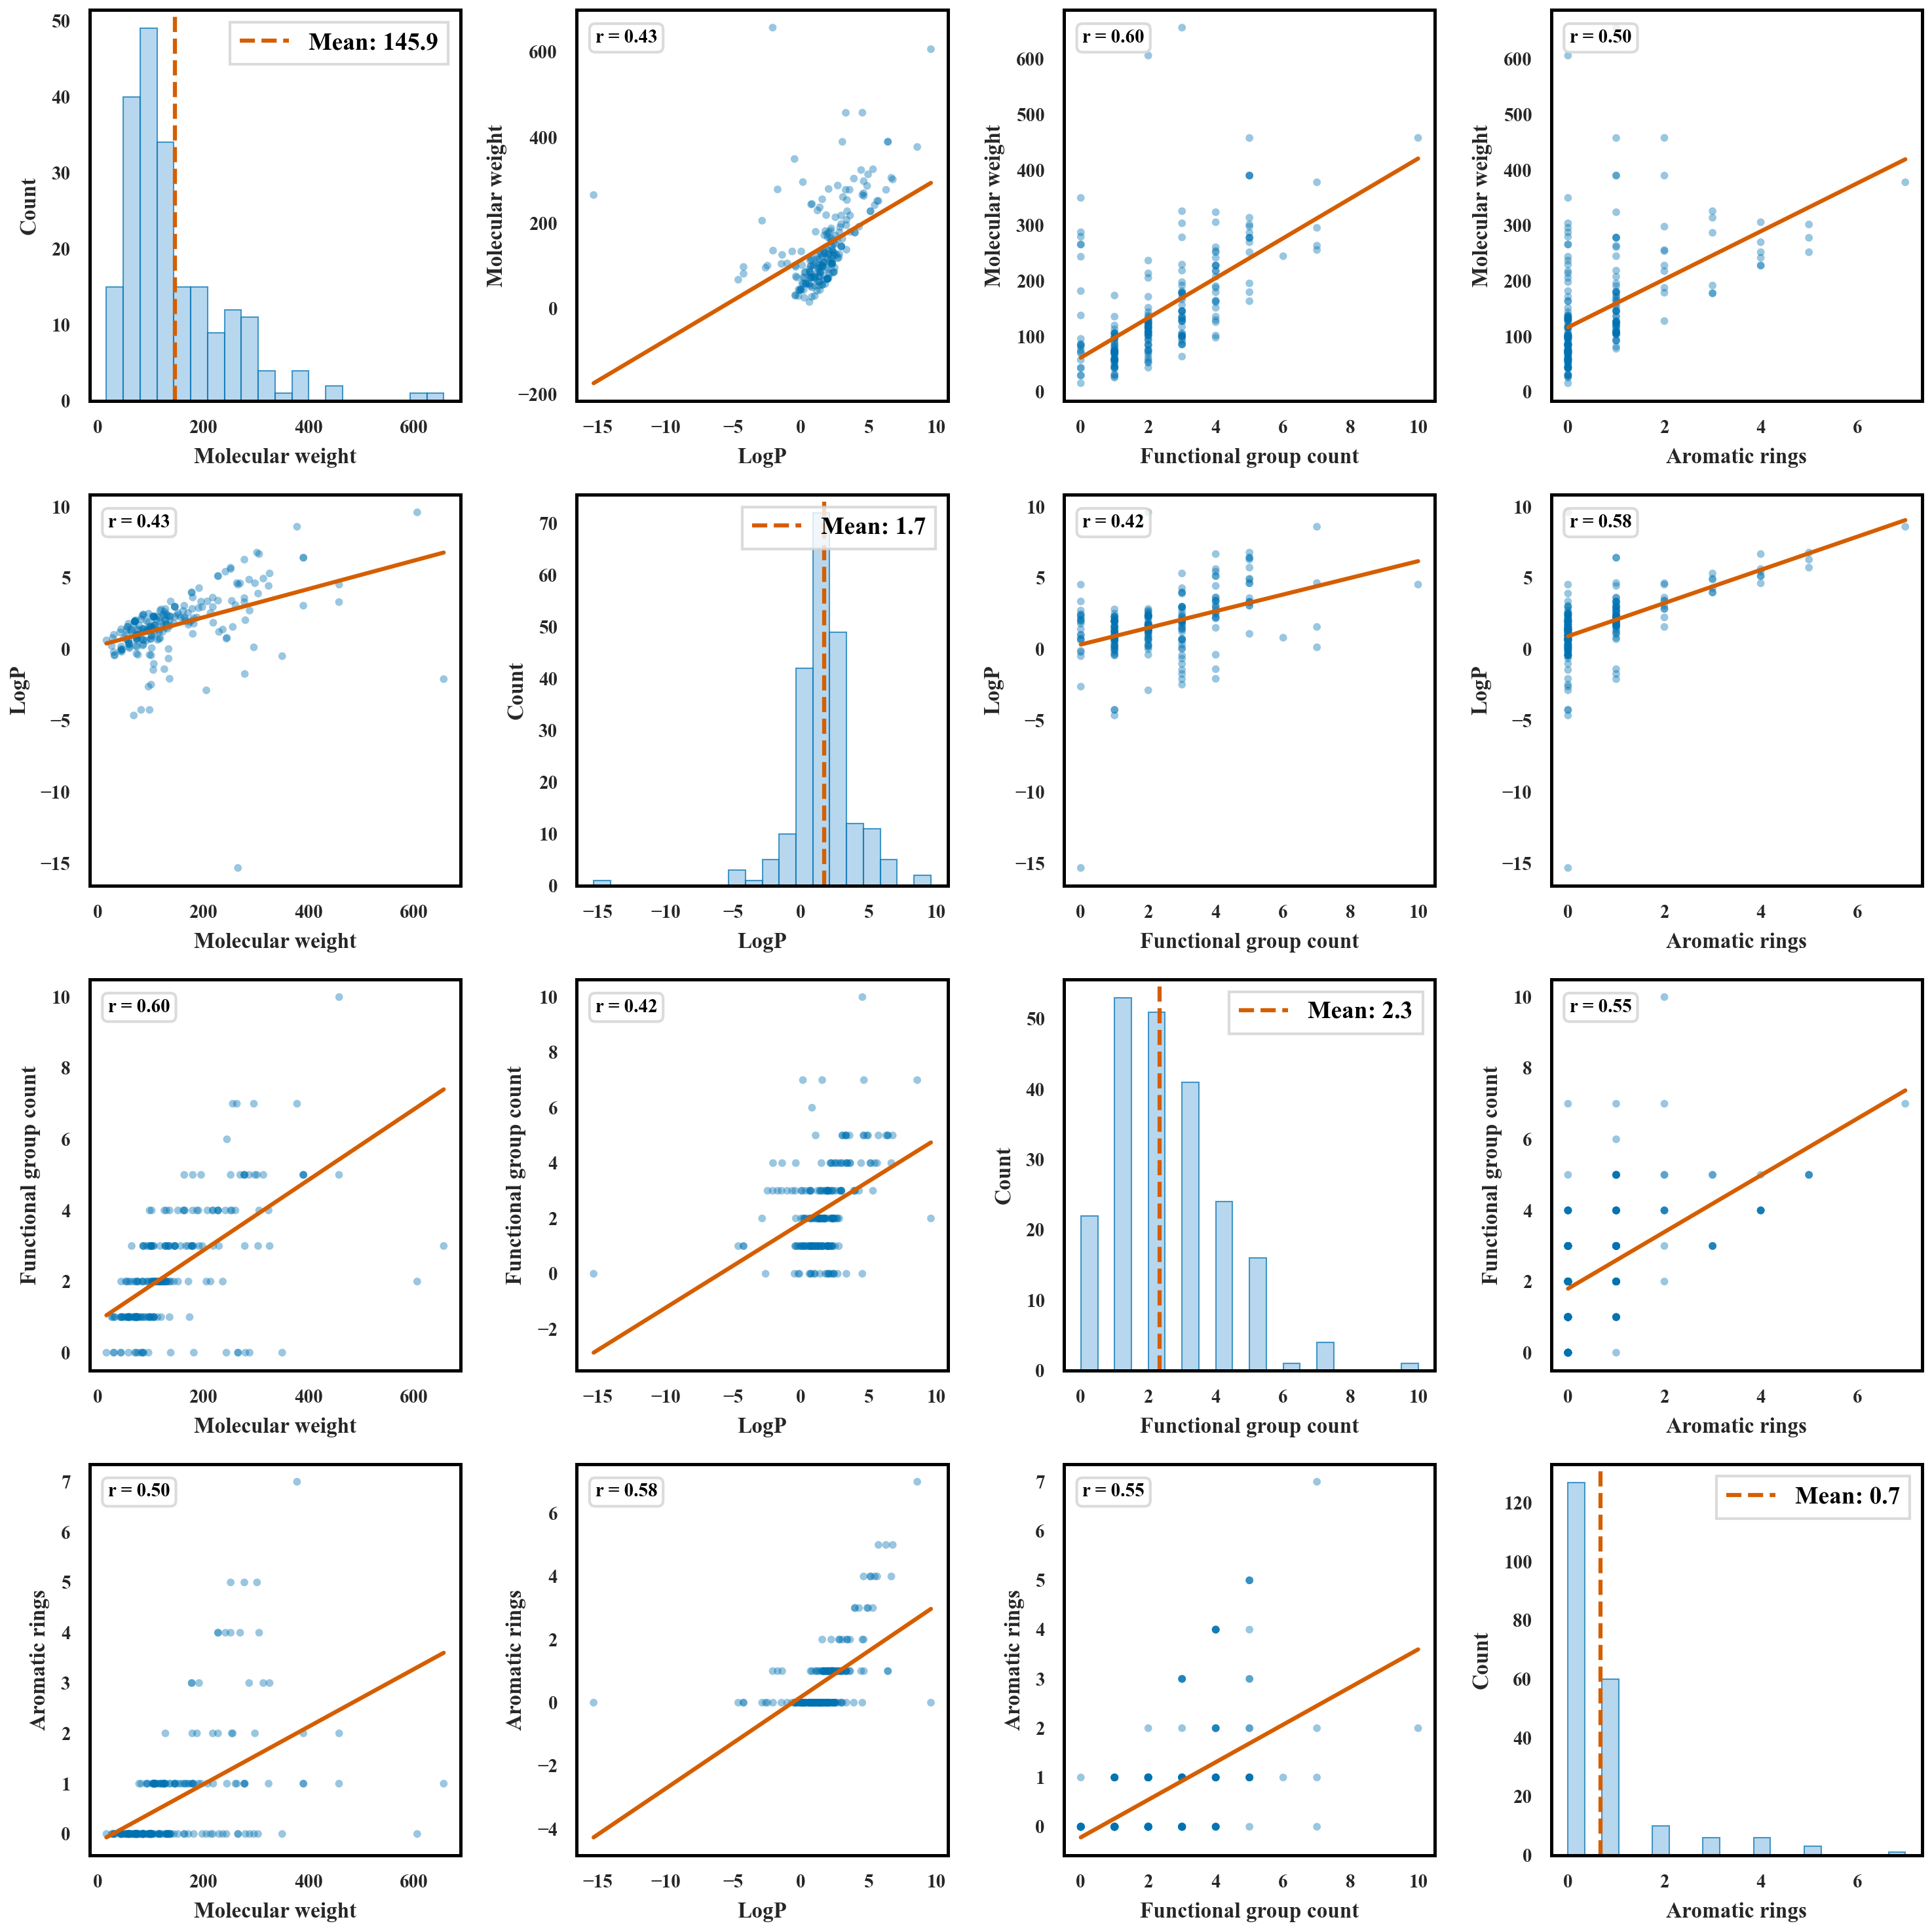


Exporting special compound lists...
✓ PAHs (≥3 rings): 16 compounds
✓ Heavy metal compounds: 5 compounds
✓ High FG compounds (≥5): 22 compounds

ANALYSIS COMPLETE

Output files in current working directory:
1. Fig1_FG_Distribution_with_structures.svg/eps    - Functional group analysis with structures
2. Fig1_FG_Distribution_no_structures.svg/eps      - Functional group analysis (text only)
3. Fig2_Property_Distributions.svg/eps             - Property distributions (each with mean/std)
4. Fig3_Compound_Classification.svg/eps            - Compound classification
5. Fig4_Scatter_Matrix.svg/eps                     - Property correlations

✓ ALL FILES ARE EDITABLE VECTOR GRAPHICS
✓ All fonts are BOLD
✓ Open in Adobe Illustrator, Inkscape, CorelDRAW, etc.
✓ All text is editable, all elements are selectable

Data tables in CSV format available in current directory


In [1]:
# -*- coding: utf-8 -*-
"""
Carcinogen Dataset Analysis and Visualization
Nature Journal Style with Times New Roman font
Clean, professional, colorblind-friendly
Output: Editable vector graphics (SVG/EPS) - FULLY EDITABLE
All fonts BOLD
"""

import pandas as pd
import numpy as np
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, Descriptors, Crippen, Lipinski, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
import os
from io import BytesIO
from PIL import Image
import matplotlib.offsetbox as offsetbox
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
warnings.filterwarnings('ignore')

# ==================== Font and Style Configuration ====================

# Set Times New Roman as primary font - BOLD
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'  # Make all fonts bold
plt.rcParams['mathtext.fontset'] = 'stix'  # STIX math font that matches Times New Roman
plt.rcParams['mathtext.default'] = 'regular'  # Use regular math font
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

# Font sizes
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 12

# Figure settings for vector graphics
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.05
plt.rcParams['axes.linewidth'] = 1.2  # Slightly thicker axis lines
plt.rcParams['lines.linewidth'] = 1.5  # Slightly thicker lines

# Vector format settings - CRITICAL for editability
plt.rcParams['svg.fonttype'] = 'none'  # Keep fonts as text in SVG (editable)
plt.rcParams['pdf.fonttype'] = 42  # Not used but kept for compatibility
plt.rcParams['ps.fonttype'] = 42   # For EPS output - keeps text as editable

# Axis settings - no grid by default
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# Make all text elements bold by default
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold titles
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Seaborn style - minimal with bold fonts
sns.set_style("white", {
    'axes.grid': False,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'font.weight': 'bold',
    'text.color': 'black',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

# Nature's recommended color palette (colorblind-friendly)
NATURE_COLORS = {
    # Primary colors - used for main data series
    'blue': '#0072B2',      # Nature blue - primary
    'orange': '#D55E00',     # Nature orange-red - secondary
    'green': '#009E73',      # Nature green - positive/accent
    'yellow': '#F0E442',     # Nature yellow - highlight
    'cyan': '#56B4E9',       # Nature light blue - alternative
    'purple': '#CC79A7',     # Nature purple - categorical
    'red': '#D55E00',        # Nature red/orange
    'grey': '#999999',       # Nature grey - neutral
    
    # Secondary/light versions
    'light_blue': '#99C7E8',
    'light_orange': '#F0B89A',
    'light_green': '#9FD6C0',
    'light_grey': '#CCCCCC',
    
    # Sequential gradients
    'blue_gradient': ['#F7FBFF', '#DEEBF7', '#C6DBEF', '#9ECAE1', '#6BAED6', '#4292C6', '#2171B5', '#08519C', '#08306B'],
}

# Suppress RDKit warnings
RDLogger.DisableLog('rdApp.*')


# ==================== Vector Graphics Utility Functions ====================

def save_figure_editable(fig, filename, formats=None, dpi=300, **kwargs):
    """
    Save figure in editable vector formats (SVG, EPS) directly to working directory
    
    Parameters:
    -----------
    fig : matplotlib.figure.Figure
        Figure to save
    filename : str
        Base filename without extension
    formats : list
        List of formats to save ('svg', 'eps')
    dpi : int
        Resolution for raster preview (not used for vector)
    """
    if formats is None:
        formats = ['svg', 'eps']  # Default to fully editable vector formats
    
    # Get base filename without path
    base_name = os.path.basename(filename)
    base_name = os.path.splitext(base_name)[0]
    
    saved_files = []
    for fmt in formats:
        output_path = f"{base_name}.{fmt}"  # Save directly to working directory
        
        # Format-specific settings for maximum editability
        if fmt == 'svg':
            # SVG settings for editability
            fig.savefig(output_path, format='svg', bbox_inches='tight', 
                       pad_inches=0.05,
                       metadata={'Creator': 'Carcinogen Analysis Tool'},
                       **kwargs)
            print(f"  ✓ Saved editable SVG: {output_path}")
            
        elif fmt == 'eps':
            # EPS settings for editability
            fig.savefig(output_path, format='eps', bbox_inches='tight', 
                       pad_inches=0.05, dpi=dpi,
                       **kwargs)
            print(f"  ✓ Saved editable EPS: {output_path}")
            
        elif fmt == 'pdf':
            # PDF is not fully editable in all software, but included as option
            fig.savefig(output_path, format='pdf', bbox_inches='tight', 
                       pad_inches=0.05, dpi=dpi,
                       **kwargs)
            print(f"  ✓ Saved PDF: {output_path} (may have limited editability)")
        
        saved_files.append(output_path)
    
    return saved_files


# ==================== Functional Group Structure Generator ====================

class FunctionalGroupStructureGenerator:
    """Generate 2D structures for functional groups"""
    
    def __init__(self):
        # Define SMILES for representative functional groups
        self.fg_smiles = {
            # Oxygen-containing
            'Alcohol(OH)': 'CCO',  # Ethanol
            'Phenol': 'c1ccccc1O',  # Phenol
            'Aldehyde': 'CC=O',  # Acetaldehyde
            'Ketone': 'CC(=O)C',  # Acetone
            'Carboxylic_acid': 'CC(=O)O',  # Acetic acid
            'Carboxylate': 'CC(=O)[O-]',  # Acetate
            'Ester': 'CC(=O)OCC',  # Ethyl acetate
            'Ether': 'CCOCC',  # Diethyl ether
            'Peroxide': 'CCOOC',  # Ethyl peroxide
            
            # Nitrogen-containing
            'Amine_primary': 'CCN',  # Ethylamine
            'Amine_secondary': 'CCNC',  # Methylethylamine
            'Amine_tertiary': 'CCN(CC)CC',  # Triethylamine
            'Quaternary_N': 'C[N+](C)(C)C',  # Tetramethylammonium
            'Amide': 'CC(=O)N',  # Acetamide
            'Nitro': 'CC[N+](=O)[O-]',  # Nitroethane
            'Nitrile': 'CC#N',  # Acetonitrile
            'Azo': 'CCN=NC',  # Azoethane
            'Azide': 'CCN=[N+]=[N-]',  # Ethyl azide
            
            # Sulfur-containing
            'Thiol': 'CCS',  # Ethanethiol
            'Sulfide': 'CCSC',  # Ethyl methyl sulfide
            'Disulfide': 'CCSSCC',  # Diethyl disulfide
            'Sulfoxide': 'CCS(=O)C',  # Ethyl methyl sulfoxide
            'Sulfone': 'CCS(=O)(=O)C',  # Ethyl methyl sulfone
            'Sulfonic_acid': 'CCS(=O)(=O)O',  # Ethanesulfonic acid
            'Sulfonate': 'CCS(=O)(=O)[O-]',  # Ethanesulfonate
            
            # Halogens
            'Fluoride': 'CCF',  # Fluoroethane
            'Chloride': 'CCCl',  # Chloroethane
            'Bromide': 'CCBr',  # Bromoethane
            'Iodide': 'CCI',  # Iodoethane
            
            # Unsaturated bonds
            'Alkene': 'CC=C',  # Propene
            'Alkyne': 'CC#C',  # Propyne
            'Aromatic_ring': 'c1ccccc1',  # Benzene
            
            # Special groups
            'Epoxide': 'CC1OC1',  # Methyloxirane
            'Acetal': 'CC(OC)OC',  # Acetaldehyde dimethyl acetal
            'Carbamate': 'CC(=O)NCC',  # Ethyl carbamate
            'Urea': 'NC(=O)N',  # Urea
        }
        
        # Generate structures
        self.fg_mols = {}
        self.fg_imgs = {}
        self._generate_structures()
    
    def _generate_structures(self, img_size=(60, 60)):
        """Generate 2D structures for all functional groups"""
        for fg_name, smiles in self.fg_smiles.items():
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                # Sanitize and prepare molecule
                try:
                    Chem.SanitizeMol(mol)
                    mol = Chem.AddHs(mol)
                    
                    # Generate 2D coordinates
                    from rdkit.Chem import AllChem
                    AllChem.Compute2DCoords(mol)
                    
                    # Draw molecule
                    drawer = rdMolDraw2D.MolDraw2DCairo(img_size[0], img_size[1])
                    drawer.drawOptions().bondLineWidth = 3  # Thicker bonds for bold look
                    drawer.drawOptions().fontSize = 0  # No text labels for cleaner look
                    drawer.DrawMolecule(mol)
                    drawer.FinishDrawing()
                    
                    # Convert to PIL Image
                    png_data = drawer.GetDrawingText()
                    img = Image.open(BytesIO(png_data))
                    
                    # Convert to numpy array for matplotlib
                    img_array = np.array(img)
                    
                    self.fg_mols[fg_name] = mol
                    self.fg_imgs[fg_name] = img_array
                except:
                    print(f"Warning: Could not generate structure for {fg_name}")
                    self.fg_mols[fg_name] = None
                    self.fg_imgs[fg_name] = None
            else:
                self.fg_mols[fg_name] = None
                self.fg_imgs[fg_name] = None
    
    def get_image(self, fg_name, size=(40, 40)):
        """Get structure image for functional group"""
        if fg_name in self.fg_imgs and self.fg_imgs[fg_name] is not None:
            return OffsetImage(self.fg_imgs[fg_name], zoom=0.5)
        return None


# ==================== 1. Analyzer Class (unchanged) ====================

class BatchFGAnalyzer:
    """Batch functional group analyzer"""
    
    def __init__(self, smiles_col='SMILES', id_col=None, n_jobs=4):
        self.smiles_col = smiles_col
        self.id_col = id_col
        self.n_jobs = n_jobs
        
        # Define functional group patterns
        self.fg_patterns = {
            # Oxygen-containing
            'Alcohol(OH)': '[CX4;!$(C=O)]-[OX2H]',
            'Phenol': '[c]-[OX2H]',
            'Aldehyde': '[CX3H1](=O)[#6]',
            'Ketone': '[#6][CX3](=O)[#6]',
            'Carboxylic_acid': '[CX3](=O)[OX2H1]',
            'Carboxylate': '[CX3](=O)[O-]',
            'Ester': '[#6][CX3](=O)[OX2][#6]',
            'Ether': '[OD2]([#6])[#6]',
            'Peroxide': '[OX2][OX2]',
            
            # Nitrogen-containing
            'Amine_primary': '[NX3;H2;!$(NC=O)]',
            'Amine_secondary': '[NX3;H1;!$(NC=O)]',
            'Amine_tertiary': '[NX3;H0;!$(NC=O)]',
            'Quaternary_N': '[N+X4]',
            'Amide': '[CX3](=O)[NX3]',
            'Nitro': '[NX3](=O)=O',
            'Nitrile': '[CX2]#[NX1]',
            'Azo': '[#6]-[NX2]=[NX2]-[#6]',
            'Azide': '[NX2-]=[NX2+]=[NX1-]',
            
            # Sulfur-containing
            'Thiol': '[SX2H]',
            'Sulfide': '[SX2H0]([#6])[#6]',
            'Disulfide': '[#6][SX2][SX2][#6]',
            'Sulfoxide': '[SX3](=[OX1])([#6])[#6]',
            'Sulfone': '[SX4](=[OX1])(=[OX1])([#6])[#6]',
            'Sulfonic_acid': '[SX4](=O)(=O)[OX2H]',
            'Sulfonate': '[SX4](=O)(=O)[O-]',
            
            # Halogens
            'Fluoride': '[#6]-F',
            'Chloride': '[#6]-Cl',
            'Bromide': '[#6]-Br',
            'Iodide': '[#6]-I',
            
            # Unsaturated bonds
            'Alkene': '[CX3]=[CX3]',
            'Alkyne': '[CX2]#[CX2]',
            'Aromatic_ring': '[a]1[a][a][a][a][a]1',
            
            # Special groups
            'Epoxide': 'C1OC1',
            'Acetal': '[CX4](-[OX2])(-[OX2])-[#6]',
            'Carbamate': '[NX3][CX3](=O)[OX2]',
            'Urea': '[NX3][CX3](=O)[NX3]',
        }
        
        # Compile SMARTS
        self.patterns = {}
        for name, smarts in self.fg_patterns.items():
            pat = Chem.MolFromSmarts(smarts)
            if pat is not None:
                self.patterns[name] = pat
    
    def analyze_single(self, smiles):
        """Analyze single molecule"""
        if pd.isna(smiles) or not isinstance(smiles, str):
            return {'Valid': False, 'Error': 'Empty SMILES'}
        
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return {'Valid': False, 'Error': 'Invalid SMILES'}
        
        try:
            mol = Chem.AddHs(mol)
            Chem.SanitizeMol(mol)
        except:
            pass
        
        # Basic properties
        result = {
            'Valid': True,
            'Molecular_Formula': self._get_formula(mol),
            'Molecular_Weight': round(self._get_weight(mol), 3),
            'LogP': round(self._get_logp(mol), 3),
            'HBD': self._get_hbd(mol),
            'HBA': self._get_hba(mol),
            'Rotatable_Bonds': self._get_rotatable_bonds(mol),
            'Aromatic_Rings': self._get_aromatic_rings(mol),
            'Total_Rings': self._get_total_rings(mol),
            'Charge': sum(atom.GetFormalCharge() for atom in mol.GetAtoms()),
            'Num_Atoms': mol.GetNumAtoms(),
            'Num_Heavy_Atoms': mol.GetNumHeavyAtoms(),
        }
        
        # Match functional groups
        for fg_name, pattern in self.patterns.items():
            matches = mol.GetSubstructMatches(pattern)
            result[fg_name] = len(matches)
        
        # Calculate total functional group count
        fg_cols = [col for col in self.fg_patterns.keys()]
        result['Total_FG_Count'] = sum(result.get(col, 0) for col in fg_cols)
        
        return result
    
    def _get_formula(self, mol):
        from rdkit.Chem.rdMolDescriptors import CalcMolFormula
        return CalcMolFormula(mol)
    
    def _get_weight(self, mol):
        return Descriptors.ExactMolWt(mol)
    
    def _get_logp(self, mol):
        return Crippen.MolLogP(mol)
    
    def _get_hbd(self, mol):
        return Lipinski.NumHDonors(mol)
    
    def _get_hba(self, mol):
        return Lipinski.NumHAcceptors(mol)
    
    def _get_rotatable_bonds(self, mol):
        return Lipinski.NumRotatableBonds(mol)
    
    def _get_aromatic_rings(self, mol):
        return rdMolDescriptors.CalcNumAromaticRings(mol)
    
    def _get_total_rings(self, mol):
        return rdMolDescriptors.CalcNumRings(mol)
    
    def process_csv(self, input_file, output_file=None, max_rows=None):
        """Process CSV file"""
        start_time = time.time()
        
        df = pd.read_csv(input_file)
        if max_rows:
            df = df.head(max_rows)
        
        print(f"Reading file: {input_file}")
        print(f"Total compounds: {len(df)}")
        
        if self.smiles_col not in df.columns:
            raise ValueError(f"Column '{self.smiles_col}' does not exist")
        
        results_list = []
        
        # Single thread processing
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Analyzing molecules"):
            smiles = row[self.smiles_col]
            result = self.analyze_single(smiles)
            results_list.append(result)
        
        results_df = pd.DataFrame(results_list)
        final_df = pd.concat([df.reset_index(drop=True), results_df], axis=1)
        
        valid_count = final_df['Valid'].sum()
        print(f"\nProcessing complete!")
        print(f"Valid molecules: {valid_count}/{len(df)} ({valid_count/len(df)*100:.1f}%)")
        print(f"Time elapsed: {time.time()-start_time:.1f} seconds")
        
        if output_file:
            self._save_results(final_df, output_file)
        
        return final_df
    
    def _save_results(self, df, output_file):
        if output_file.endswith('.csv'):
            df.to_csv(output_file, index=False, encoding='utf-8-sig')
        elif output_file.endswith('.xlsx'):
            df.to_excel(output_file, index=False, engine='openpyxl')
    
    def generate_summary(self, df):
        """Generate summary statistics"""
        fg_cols = [col for col in df.columns if col in self.fg_patterns.keys()]
        
        summary = []
        for col in fg_cols:
            has_fg = (df[col] > 0).sum()
            total = len(df)
            avg_count = df[col].mean()
            max_count = df[col].max()
            total_occ = df[col].sum()
            
            summary.append({
                'Functional_Group': col,
                'Compounds_with_FG': has_fg,
                'Percentage': has_fg/total*100,
                'Average_Count': avg_count,
                'Max_Count': max_count,
                'Total_Occurrences': total_occ
            })
        
        summary_df = pd.DataFrame(summary)
        summary_df = summary_df.sort_values('Percentage', ascending=False)
        return summary_df


# ==================== 2. Nature Journal Style Visualizer with Bold Fonts ====================

class NatureStyleVisualizer:
    """
    Visualization class following Nature journal style guidelines
    - Times New Roman font (BOLD)
    - No grid lines
    - All axes properly labeled
    - Output as editable vector graphics (SVG/EPS) in working directory
    """
    
    def __init__(self, results_df, summary_df, analyzer):
        self.df = results_df
        self.summary = summary_df
        self.analyzer = analyzer
        self.fg_cols = [col for col in results_df.columns if col in analyzer.fg_patterns.keys()]
        
        # Nature color palette
        self.colors = NATURE_COLORS
        
        # Create colormaps
        self.blue_cmap = LinearSegmentedColormap.from_list('nature_blue', self.colors['blue_gradient'])
        
        # Output formats for vector graphics - FULLY EDITABLE
        self.editable_formats = ['svg', 'eps']  # Pure vector, fully editable
        
        # Initialize functional group structure generator
        self.fg_struct = FunctionalGroupStructureGenerator()
        
    def _get_property_name(self, prop):
        """Get property display name"""
        prop_names = {
            'Molecular_Weight': 'Molecular weight',
            'LogP': 'LogP',
            'HBD': 'H-bond donors',
            'HBA': 'H-bond acceptors',
            'Rotatable_Bonds': 'Rotatable bonds',
            'Aromatic_Rings': 'Aromatic rings',
            'Total_Rings': 'Total rings',
            'Total_FG_Count': 'Functional group count',
            'Num_Atoms': 'Atom count',
            'Num_Heavy_Atoms': 'Heavy atoms',
            'Charge': 'Net charge'
        }
        return prop_names.get(prop, prop)
    
    def _apply_style(self, ax, title=None, xlabel=None, ylabel=None):
        """Apply consistent styling to axis - no grid, bold fonts"""
        if title:
            ax.set_title(title, fontsize=11, fontweight='bold', pad=8, fontfamily='Times New Roman')
        if xlabel:
            ax.set_xlabel(xlabel, fontsize=10, fontweight='bold', fontfamily='Times New Roman')
        if ylabel:
            ax.set_ylabel(ylabel, fontsize=10, fontweight='bold', fontfamily='Times New Roman')
        
        # No grid
        ax.grid(False)
        
        # Axis lines
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
            spine.set_color('black')
        
        # Tick parameters
        ax.tick_params(axis='both', which='major', length=4, width=1.2, labelsize=9)
        ax.tick_params(axis='both', which='minor', length=2, width=0.8)
        
        # Set tick label font
        for label in ax.get_xticklabels():
            label.set_fontfamily('Times New Roman')
            label.set_fontweight('bold')
        for label in ax.get_yticklabels():
            label.set_fontfamily('Times New Roman')
            label.set_fontweight('bold')
    
    def plot_functional_group_distribution(self, top_n=15, save_path=None, formats=None, show_structures=True):
        """
        Plot functional group distribution - no grid
        Optional: Show chemical structures of functional groups
        Save as editable vector graphics in working directory
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 11))
        
        # Figure 1: FG frequency with optional structures
        ax1 = axes[0, 0]
        top_fg = self.summary.head(top_n)
        
        bars = ax1.barh(range(len(top_fg)), top_fg['Percentage'].values, 
                       color=self.colors['blue'], alpha=0.9, height=0.6,
                       edgecolor='black', linewidth=0.5)
        ax1.set_yticks(range(len(top_fg)))
        
        # Prepare y-tick labels
        if show_structures:
            # Use abbreviated labels for better space management
            y_labels = []
            for fg in top_fg['Functional_Group'].values:
                # Shorten long names
                if '(' in fg:
                    short_name = fg.split('(')[0]
                else:
                    short_name = fg.replace('_', ' ')
                y_labels.append(short_name)
            ax1.set_yticklabels(y_labels, fontfamily='Times New Roman', fontsize=8, fontweight='bold')
            
            # Add structure images
            for i, fg_name in enumerate(top_fg['Functional_Group'].values):
                img = self.fg_struct.get_image(fg_name)
                if img:
                    # Position image to the left of the y-tick label
                    ab = AnnotationBbox(img, (-8, i), frameon=False,
                                       xycoords='data', boxcoords="offset points",
                                       pad=0)
                    ax1.add_artist(ab)
        else:
            ax1.set_yticklabels(top_fg['Functional_Group'].values, fontfamily='Times New Roman', fontweight='bold')
        
        self._apply_style(ax1, 
                         title='Functional group frequency',
                         xlabel='Compounds containing functional group (%)',
                         ylabel='Functional group')
        ax1.invert_yaxis()
        
        # Adjust x-axis limit to make room for structures
        if show_structures:
            xlim = ax1.get_xlim()
            ax1.set_xlim(-5, xlim[1])
        
        # Add value labels
        for i, v in enumerate(top_fg['Percentage'].values):
            ax1.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8, 
                    fontfamily='Times New Roman', fontweight='bold')
        
        # Figure 2: Average FG count
        ax2 = axes[0, 1]
        top_avg = self.summary.nlargest(top_n, 'Average_Count')
        
        bars = ax2.barh(range(len(top_avg)), top_avg['Average_Count'].values, 
                       color=self.colors['green'], alpha=0.9, height=0.6,
                       edgecolor='black', linewidth=0.5)
        ax2.set_yticks(range(len(top_avg)))
        
        if show_structures:
            y_labels = []
            for fg in top_avg['Functional_Group'].values:
                if '(' in fg:
                    short_name = fg.split('(')[0]
                else:
                    short_name = fg.replace('_', ' ')
                y_labels.append(short_name)
            ax2.set_yticklabels(y_labels, fontfamily='Times New Roman', fontsize=8, fontweight='bold')
            
            # Add structure images
            for i, fg_name in enumerate(top_avg['Functional_Group'].values):
                img = self.fg_struct.get_image(fg_name)
                if img:
                    ab = AnnotationBbox(img, (-0.5, i), frameon=False,
                                       xycoords='data', boxcoords="offset points",
                                       pad=0)
                    ax2.add_artist(ab)
        else:
            ax2.set_yticklabels(top_avg['Functional_Group'].values, fontfamily='Times New Roman', fontweight='bold')
        
        self._apply_style(ax2,
                         title='Average functional group count',
                         xlabel='Average count per molecule',
                         ylabel='Functional group')
        ax2.invert_yaxis()
        
        # Adjust x-axis limit
        if show_structures:
            xlim = ax2.get_xlim()
            ax2.set_xlim(-0.3, xlim[1])
        
        # Add value labels
        for i, v in enumerate(top_avg['Average_Count'].values):
            ax2.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8, 
                    fontfamily='Times New Roman', fontweight='bold')
        
        # Figure 3: FG count distribution
        ax3 = axes[1, 0]
        fg_count_dist = self.df['Total_FG_Count'].value_counts().sort_index()
        
        bars = ax3.bar(fg_count_dist.index, fg_count_dist.values, 
                      color=self.colors['purple'], alpha=0.9, width=0.7,
                      edgecolor='black', linewidth=0.5)
        self._apply_style(ax3,
                         title='Distribution of functional group count',
                         xlabel='Number of functional groups per molecule',
                         ylabel='Number of compounds')
        
        # Figure 4: FG correlation heatmap
        ax4 = axes[1, 1]
        if len(self.fg_cols) > 1:
            top10_fg = self.summary.head(10)['Functional_Group'].values
            fg_corr = self.df[top10_fg].corr()
            
            im = ax4.imshow(fg_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
            cbar.set_label('Pearson correlation', fontsize=9, fontweight='bold', fontfamily='Times New Roman')
            cbar.ax.tick_params(labelsize=8)
            for label in cbar.ax.get_yticklabels():
                label.set_fontfamily('Times New Roman')
                label.set_fontweight('bold')
            
            # Set ticks
            ax4.set_xticks(range(len(top10_fg)))
            ax4.set_yticks(range(len(top10_fg)))
            
            # Prepare tick labels with abbreviations if showing structures
            if show_structures:
                x_labels = []
                y_labels = []
                for fg in top10_fg:
                    if '(' in fg:
                        short_name = fg.split('(')[0]
                    else:
                        short_name = fg.replace('_', ' ')
                    x_labels.append(short_name)
                    y_labels.append(short_name)
            else:
                x_labels = top10_fg
                y_labels = top10_fg
            
            ax4.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=7, 
                               fontfamily='Times New Roman', fontweight='bold')
            ax4.set_yticklabels(y_labels, fontsize=7, fontfamily='Times New Roman', fontweight='bold')
            ax4.set_xlabel('Functional group', fontsize=10, fontweight='bold', fontfamily='Times New Roman')
            ax4.set_ylabel('Functional group', fontsize=10, fontweight='bold', fontfamily='Times New Roman')
            ax4.set_title('Functional group correlations', fontsize=11, fontweight='bold', fontfamily='Times New Roman')
            
            # Add correlation values
            for i in range(len(top10_fg)):
                for j in range(len(top10_fg)):
                    text_color = 'white' if abs(fg_corr.iloc[i, j]) > 0.5 else 'black'
                    ax4.text(j, i, f'{fg_corr.iloc[i, j]:.2f}',
                            ha='center', va='center', fontsize=6,
                            color=text_color, fontfamily='Times New Roman', fontweight='bold')
            
            # No grid for heatmap
            ax4.grid(False)
            for spine in ax4.spines.values():
                spine.set_linewidth(1.2)
        
        plt.tight_layout()
        
        # Add a note about structures if shown
        if show_structures:
            fig.text(0.5, 0.02, 'Chemical structures shown next to functional group names', 
                    ha='center', fontsize=8, fontstyle='italic', fontweight='bold', 
                    fontfamily='Times New Roman')
        
        # Save as editable vector graphics in working directory
        if save_path:
            # Use editable formats (SVG, EPS)
            save_format = formats or self.editable_formats
            
            # Add suffix for structure version
            if show_structures:
                base, ext = os.path.splitext(save_path)
                save_path_structured = f"{base}_with_structures"
                save_figure_editable(fig, save_path_structured, formats=save_format)
            else:
                save_figure_editable(fig, save_path, formats=save_format)
        
        plt.show()
        return fig
    
    def plot_property_distributions(self, save_path=None, formats=None):
        """
        Plot property distributions - no grid
        Each subplot shows mean value with annotation
        Save as editable vector graphics in working directory
        """
        prop_cols = ['Molecular_Weight', 'LogP', 'HBD', 'HBA', 
                     'Rotatable_Bonds', 'Aromatic_Rings', 'Total_Rings']
        
        n_cols = 3
        n_rows = (len(prop_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5*n_rows))
        axes = axes.flatten()
        
        property_colors = {
            'Molecular_Weight': self.colors['blue'],
            'LogP': self.colors['orange'],
            'HBD': self.colors['green'],
            'HBA': self.colors['green'],
            'Rotatable_Bonds': self.colors['purple'],
            'Aromatic_Rings': self.colors['cyan'],
            'Total_Rings': self.colors['cyan'],
        }
        
        for i, col in enumerate(prop_cols):
            if col in self.df.columns:
                data = self.df[col].dropna()
                
                # Histogram
                n, bins, patches = axes[i].hist(data, bins=25, 
                                               color=property_colors.get(col, self.colors['blue']),
                                               edgecolor='black', linewidth=0.5, alpha=0.8)
                
                # Calculate statistics
                mean_val = data.mean()
                median_val = data.median()
                std_val = data.std()
                
                # Add mean line
                mean_line = axes[i].axvline(mean_val, color=self.colors['red'], linestyle='--', 
                               linewidth=1.5, label=f'Mean: {mean_val:.1f}')
                
                # Add text annotation for statistics
                stats_text = f'Mean: {mean_val:.1f}\nStd: {std_val:.1f}'
                axes[i].text(0.95, 0.95, stats_text,
                           transform=axes[i].transAxes,
                           verticalalignment='top',
                           horizontalalignment='right',
                           fontsize=7,
                           fontfamily='Times New Roman',
                           fontweight='bold',
                           bbox=dict(boxstyle='round', facecolor='white', 
                                   edgecolor='lightgrey', alpha=0.8))
                
                self._apply_style(axes[i],
                                 title=self._get_property_name(col),
                                 xlabel=self._get_property_name(col),
                                 ylabel='Number of compounds')
                
                # Add legend for mean line
                axes[i].legend(fontsize=7, frameon=True, fancybox=False, 
                              edgecolor='lightgrey', prop={'family': 'Times New Roman', 'weight': 'bold'},
                              loc='upper left')
        
        # Hide empty subplots
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        
        # Save as editable vector graphics in working directory
        if save_path:
            save_figure_editable(fig, save_path, formats=formats or self.editable_formats)
        
        plt.show()
        return fig
    
    def plot_compound_classification(self, save_path=None, formats=None):
        """
        Plot compound classification - no grid
        Save as editable vector graphics in working directory
        """
        fig, axes = plt.subplots(2, 3, figsize=(14, 9))
        
        # 1. Aromatic vs Aliphatic
        ax1 = axes[0, 0]
        aromatic = (self.df['Aromatic_ring'] > 0).sum()
        aliphatic = len(self.df) - aromatic
        
        bars = ax1.bar(['Aromatic', 'Aliphatic'], [aromatic, aliphatic],
                       color=[self.colors['blue'], self.colors['light_blue']],
                       edgecolor='black', linewidth=0.8, width=0.6)
        self._apply_style(ax1,
                         title='Aromatic vs aliphatic compounds',
                         ylabel='Number of compounds')
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{int(height)} ({height/len(self.df)*100:.1f}%)', 
                    ha='center', va='bottom', fontsize=8, 
                    fontfamily='Times New Roman', fontweight='bold')
        
        # 2. Element-containing compounds
        ax2 = axes[0, 1]
        element_categories = {
            'N-containing': [c for c in self.fg_cols if any(x in c for x in ['Amine', 'Nitro', 'Nitrile', 'Amide', 'Azo', 'Azide'])],
            'O-containing': [c for c in self.fg_cols if any(x in c for x in ['Alcohol', 'Phenol', 'Aldehyde', 'Ketone', 'Carboxylic', 'Ester', 'Ether'])],
            'Halogen': ['Fluoride', 'Chloride', 'Bromide', 'Iodide'],
            'S-containing': [c for c in self.fg_cols if any(x in c for x in ['Thiol', 'Sulfide', 'Sulf'])]
        }
        
        element_counts = {}
        for category, cols in element_categories.items():
            mask = pd.Series([False] * len(self.df))
            valid_cols = [c for c in cols if c in self.df.columns]
            for col in valid_cols:
                mask |= (self.df[col] > 0)
            if mask.sum() > 0:
                element_counts[category] = mask.sum()
        
        bars = ax2.bar(element_counts.keys(), element_counts.values(),
                      color=[self.colors['blue'], self.colors['green'], 
                            self.colors['orange'], self.colors['purple']],
                      edgecolor='black', linewidth=0.8, width=0.6)
        self._apply_style(ax2,
                         title='Element-containing compounds',
                         ylabel='Number of compounds')
        ax2.tick_params(axis='x', rotation=45)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8, 
                    fontfamily='Times New Roman', fontweight='bold')
        
        # 3. Carcinogen classes
        ax3 = axes[0, 2]
        carcinogen_classes = {
            'PAHs (≥3 rings)': (self.df['Aromatic_Rings'] >= 3).sum(),
            'Aromatic amines': ((self.df['Aromatic_ring'] > 0) & 
                                ((self.df['Amine_primary'] > 0) | (self.df['Amine_secondary'] > 0))).sum(),
            'Halogenated': ((self.df['Chloride'] > 0) | (self.df['Bromide'] > 0)).sum(),
            'Nitrosamines': self.df['SMILES'].str.contains('N=O', na=False).sum()
        }
        carcinogen_classes = {k: v for k, v in carcinogen_classes.items() if v > 0}
        
        bars = ax3.bar(carcinogen_classes.keys(), carcinogen_classes.values(),
                      color=[self.colors['blue'], self.colors['orange'], 
                            self.colors['green'], self.colors['purple']],
                      edgecolor='black', linewidth=0.8, width=0.6)
        self._apply_style(ax3,
                         title='Carcinogen classes',
                         ylabel='Number of compounds')
        ax3.tick_params(axis='x', rotation=45)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8, 
                    fontfamily='Times New Roman', fontweight='bold')
        
        # 4. Lipinski rules
        ax4 = axes[1, 0]
        def check_lipinski(row):
            violations = 0
            if row.get('Molecular_Weight', 0) > 500: violations += 1
            if row.get('LogP', 0) > 5: violations += 1
            if row.get('HBD', 0) > 5: violations += 1
            if row.get('HBA', 0) > 10: violations += 1
            return violations
        
        violations = self.df.apply(check_lipinski, axis=1)
        lipinski_counts = [
            (violations == 0).sum(),
            (violations == 1).sum(),
            (violations >= 2).sum()
        ]
        lipinski_labels = ['0 violations', '1 violation', '≥2 violations']
        
        bars = ax4.bar(lipinski_labels, lipinski_counts, 
                       color=[self.colors['green'], self.colors['orange'], self.colors['red']],
                       edgecolor='black', linewidth=0.8, width=0.6)
        self._apply_style(ax4,
                         title='Lipinski rule compliance',
                         ylabel='Number of compounds')
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8, 
                    fontfamily='Times New Roman', fontweight='bold')
        
        # 5. Molecular weight distribution
        ax5 = axes[1, 1]
        mw_bins = [0, 200, 400, 600, 800, 1000, 2000]
        mw_labels = ['<200', '200-400', '400-600', '600-800', '800-1000', '>1000']
        mw_cats = pd.cut(self.df['Molecular_Weight'], bins=mw_bins, labels=mw_labels)
        mw_dist = mw_cats.value_counts().sort_index()
        
        bars = ax5.bar(range(len(mw_dist)), mw_dist.values, 
                      color=self.colors['blue'], edgecolor='black', linewidth=0.8, width=0.7)
        ax5.set_xticks(range(len(mw_dist)))
        ax5.set_xticklabels(mw_dist.index, fontfamily='Times New Roman', fontweight='bold')
        self._apply_style(ax5,
                         title='Molecular weight distribution',
                         xlabel='Molecular weight range',
                         ylabel='Number of compounds')
        
        # Add value labels
        for i, v in enumerate(mw_dist.values):
            ax5.text(i, v + 2, str(v), ha='center', va='bottom', fontsize=8, 
                    fontfamily='Times New Roman', fontweight='bold')
        
        # 6. Ring number distribution
        ax6 = axes[1, 2]
        ring_dist = self.df['Total_Rings'].value_counts().sort_index()
        if len(ring_dist) > 7:
            ring_dist = ring_dist.head(7)
        
        bars = ax6.bar(range(len(ring_dist)), ring_dist.values,
                      color=self.colors['green'], edgecolor='black', linewidth=0.8, width=0.7)
        ax6.set_xticks(range(len(ring_dist)))
        ax6.set_xticklabels(ring_dist.index.astype(str), fontfamily='Times New Roman', fontweight='bold')
        self._apply_style(ax6,
                         title='Ring number distribution',
                         xlabel='Number of rings',
                         ylabel='Number of compounds')
        
        # Add value labels
        for i, v in enumerate(ring_dist.values):
            ax6.text(i, v + 2, str(v), ha='center', va='bottom', fontsize=8, 
                    fontfamily='Times New Roman', fontweight='bold')
        
        plt.tight_layout()
        
        # Save as editable vector graphics in working directory
        if save_path:
            save_figure_editable(fig, save_path, formats=formats or self.editable_formats)
        
        plt.show()
        return fig
    
    def plot_scatter_matrix(self, save_path=None, formats=None):
        """
        Plot scatter matrix - no grid
        Save as editable vector graphics in working directory
        """
        props = ['Molecular_Weight', 'LogP', 'Total_FG_Count', 'Aromatic_Rings']
        available_props = [p for p in props if p in self.df.columns]
        
        if len(available_props) >= 2:
            n = len(available_props)
            fig, axes = plt.subplots(n, n, figsize=(10, 10))
            
            for i in range(n):
                for j in range(n):
                    ax = axes[i, j]
                    prop1 = available_props[i]
                    prop2 = available_props[j]
                    
                    if i == j:
                        # Diagonal: histogram
                        data = self.df[prop1].dropna()
                        ax.hist(data, bins=20, color=self.colors['light_blue'], 
                               edgecolor=self.colors['blue'], linewidth=0.5, alpha=0.7)
                        
                        # Add mean line on diagonal
                        mean_val = data.mean()
                        ax.axvline(mean_val, color=self.colors['red'], linestyle='--', 
                                  linewidth=1.5, label=f'Mean: {mean_val:.1f}')
                        
                        ax.set_xlabel(self._get_property_name(prop1), fontsize=8, 
                                    fontfamily='Times New Roman', fontweight='bold')
                        ax.set_ylabel('Count', fontsize=8, fontfamily='Times New Roman', fontweight='bold')
                        
                        # Add legend for diagonal
                        ax.legend(fontsize=6, frameon=True, fancybox=False, 
                                 edgecolor='lightgrey', prop={'family': 'Times New Roman', 'weight': 'bold'},
                                 loc='upper right')
                    else:
                        # Off-diagonal: scatter plot
                        x = self.df[prop2].dropna()
                        y = self.df[prop1].dropna()
                        
                        valid_idx = x.index.intersection(y.index)
                        x = x.loc[valid_idx]
                        y = y.loc[valid_idx]
                        
                        ax.scatter(x, y, alpha=0.4, s=8, color=self.colors['blue'],
                                  edgecolor='none')
                        
                        # Add trend line
                        if len(x) > 5:
                            z = np.polyfit(x, y, 1)
                            p = np.poly1d(z)
                            x_sorted = np.sort(x)
                            ax.plot(x_sorted, p(x_sorted), 
                                   color=self.colors['red'], linestyle='-', linewidth=1.5)
                            
                            # Add correlation coefficient
                            corr = np.corrcoef(x, y)[0, 1]
                            ax.text(0.05, 0.95, f'r = {corr:.2f}',
                                   transform=ax.transAxes,
                                   verticalalignment='top',
                                   horizontalalignment='left',
                                   fontsize=7,
                                   fontfamily='Times New Roman',
                                   fontweight='bold',
                                   bbox=dict(boxstyle='round', facecolor='white', 
                                           edgecolor='lightgrey', alpha=0.8))
                        
                        ax.set_xlabel(self._get_property_name(prop2), fontsize=8, 
                                    fontfamily='Times New Roman', fontweight='bold')
                        ax.set_ylabel(self._get_property_name(prop1), fontsize=8, 
                                    fontfamily='Times New Roman', fontweight='bold')
                    
                    # Apply styling - no grid
                    ax.grid(False)
                    ax.tick_params(labelsize=7)
                    for label in ax.get_xticklabels():
                        label.set_fontfamily('Times New Roman')
                        label.set_fontweight('bold')
                    for label in ax.get_yticklabels():
                        label.set_fontfamily('Times New Roman')
                        label.set_fontweight('bold')
                    for spine in ax.spines.values():
                        spine.set_linewidth(1.2)
                        spine.set_color('black')
            
            plt.tight_layout()
            
            # Save as editable vector graphics in working directory
            if save_path:
                save_figure_editable(fig, save_path, formats=formats or self.editable_formats)
            
            plt.show()
            return fig
    
    def print_statistics(self):
        """Print detailed statistics in Nature paper style"""
        print("\n" + "="*80)
        print("CARCINOGEN DATASET STATISTICAL SUMMARY")
        print("="*80)
        print(f"\nDataset size: {len(self.df)} compounds")
        print(f"Valid molecules: {self.df['Valid'].sum()} ({self.df['Valid'].sum()/len(self.df)*100:.1f}%)")
        
        print("\nPhysicochemical properties (mean ± s.d.)")
        for col in ['Molecular_Weight', 'LogP', 'HBD', 'HBA', 'Rotatable_Bonds', 'Total_Rings']:
            if col in self.df.columns:
                mean_val = self.df[col].mean()
                std_val = self.df[col].std()
                print(f"  {self._get_property_name(col):18s}: {mean_val:.1f} ± {std_val:.1f}")
        
        print("\nFunctional group prevalence (top 5)")
        top5 = self.summary.head(5)
        for _, row in top5.iterrows():
            print(f"  {row['Functional_Group']:25s}: {row['Percentage']:.1f}% (avg {row['Average_Count']:.2f} per molecule)")


# ==================== 3. Main Program ====================

if __name__ == "__main__":
    
    print("="*80)
    print("CARCINOGEN DATASET ANALYSIS - NATURE JOURNAL STYLE")
    print("="*80)
    print("Features:")
    print("- Times New Roman font throughout (BOLD)")
    print("- No grid lines")
    print("- Colorblind-friendly palette")
    print("- All axes properly labeled")
    print("- EDITABLE VECTOR GRAPHICS (SVG/EPS) in working directory")
    print("- Chemical structures for functional groups")
    print("- Fully editable in Illustrator, Inkscape, CorelDRAW")
    
    # 1. Initialize analyzer
    analyzer = BatchFGAnalyzer(
        smiles_col='SMILES',
        id_col='Compound_CID',
        n_jobs=4
    )
    
    # 2. Process data
    results = analyzer.process_csv(
        input_file='致癌物.csv',
        output_file='carcinogen_fg_analysis_results.xlsx'
    )
    
    # 3. Generate summary statistics
    summary = analyzer.generate_summary(results)
    summary.to_csv('carcinogen_fg_statistics.csv', index=False, encoding='utf-8-sig')
    
    print("\nFunctional group statistics saved to: carcinogen_fg_statistics.csv")
    print("Detailed results saved to: carcinogen_fg_analysis_results.xlsx")
    
    # 4. Initialize Nature-style visualizer
    viz = NatureStyleVisualizer(results, summary, analyzer)
    
    # 5. Print statistics
    viz.print_statistics()
    
    # 6. Generate Nature-style plots as editable vector graphics in working directory
    print("\n" + "="*80)
    print("Generating EDITABLE VECTOR GRAPHICS (SVG/EPS)...")
    print("="*80)
    print("Files saved directly to current working directory")
    print("These files are FULLY EDITABLE in vector graphics software")
    
    # Figure 1: FG distribution - with chemical structures
    print("\nFigure 1: Functional Group Distribution (with chemical structures)")
    viz.plot_functional_group_distribution(top_n=15, save_path='Fig1_FG_Distribution_with_structures', show_structures=True)
    
    # Also save a version without structures for comparison (optional)
    print("\nFigure 1b: Functional Group Distribution (without structures)")
    viz.plot_functional_group_distribution(top_n=15, save_path='Fig1_FG_Distribution_no_structures', show_structures=False)
    
    # Figure 2: Property distributions - each subplot now shows mean and stats
    print("\nFigure 2: Property Distributions")
    viz.plot_property_distributions(save_path='Fig2_Property_Distributions')
    
    # Figure 3: Compound classification
    print("\nFigure 3: Compound Classification")
    viz.plot_compound_classification(save_path='Fig3_Compound_Classification')
    
    # Figure 4: Scatter matrix
    print("\nFigure 4: Scatter Matrix")
    viz.plot_scatter_matrix(save_path='Fig4_Scatter_Matrix')
    
    # 7. Export special compound lists
    print("\n" + "="*80)
    print("Exporting special compound lists...")
    print("="*80)
    
    # PAHs
    pah = results[results['Aromatic_Rings'] >= 3]
    pah.to_csv('carcinogen_pahs.csv', index=False, encoding='utf-8-sig')
    print(f"✓ PAHs (≥3 rings): {len(pah)} compounds")
    
    # Heavy metal compounds
    heavy_metals = results[results['SMILES'].str.contains('Hg|Pb|Cd|As|Sb|Au', na=False)]
    heavy_metals.to_csv('carcinogen_heavy_metals.csv', index=False, encoding='utf-8-sig')
    print(f"✓ Heavy metal compounds: {len(heavy_metals)} compounds")
    
    # High FG compounds
    high_fg = results[results['Total_FG_Count'] >= 5]
    high_fg.to_csv('carcinogen_high_fg.csv', index=False, encoding='utf-8-sig')
    print(f"✓ High FG compounds (≥5): {len(high_fg)} compounds")
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)
    print("\nOutput files in current working directory:")
    print("1. Fig1_FG_Distribution_with_structures.svg/eps    - Functional group analysis with structures")
    print("2. Fig1_FG_Distribution_no_structures.svg/eps      - Functional group analysis (text only)")
    print("3. Fig2_Property_Distributions.svg/eps             - Property distributions (each with mean/std)")
    print("4. Fig3_Compound_Classification.svg/eps            - Compound classification")
    print("5. Fig4_Scatter_Matrix.svg/eps                     - Property correlations")
    print("\n✓ ALL FILES ARE EDITABLE VECTOR GRAPHICS")
    print("✓ All fonts are BOLD")
    print("✓ Open in Adobe Illustrator, Inkscape, CorelDRAW, etc.")
    print("✓ All text is editable, all elements are selectable")
    print("\nData tables in CSV format available in current directory")